# MediaScrape Semantic Upgrade Demo

This notebook compares a TF-IDF baseline against the new hybrid semantic retrieval pipeline,
then visualizes stored text embeddings with PCA.

In [6]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from models import SessionLocal, MediaItem
from search import search_by_text

In [7]:
db = SessionLocal()
rows = (
    db.query(MediaItem)
    .filter(MediaItem.is_indexed.is_(True))
    .order_by(MediaItem.id.asc())
    .all()
)
db.close()

records = []
for row in rows:
    records.append({
        'id': row.id,
        'title': row.title or '',
        'description': row.description or '',
        'media_type': row.media_type or '',
        'url': row.url,
        'text_embedding': row.text_embedding,
    })

df = pd.DataFrame(records)
df['text'] = (df['title'].fillna('') + ' ' + df['description'].fillna('')).str.strip()
print('Indexed rows:', len(df))
df.head(3)

Indexed rows: 2138


,id,title,description,media_type,url,text_embedding,text
0,1,BBC TopGear,For sale: one very lightly used motor car… tha...,image,https://www.topgear.com/_next/static/images/tg...,"[0.02253156527876854, 0.05920582637190819, -0....",BBC TopGear For sale: one very lightly used mo...
1,2,BBC TopGear,For sale: one very lightly used motor car… tha...,image,https://www.topgear.com/_next/static/images/tg...,"[0.02253156527876854, 0.05920582637190819, -0....",BBC TopGear For sale: one very lightly used mo...
2,3,BBC TopGear,For sale: one very lightly used motor car… tha...,image,https://www.topgear.com/_next/static/images/mo...,"[0.02253156527876854, 0.05920582637190819, -0....",BBC TopGear For sale: one very lightly used mo...


In [8]:
def tfidf_search(query: str, top_n: int = 5) -> list[dict]:
    corpus = df['text'].tolist()
    if not corpus or not any(text.strip() for text in corpus):
        return []

    vectorizer = TfidfVectorizer(stop_words='english')
    matrix = vectorizer.fit_transform(corpus)

    try:
        query_vec = vectorizer.transform([query])
    except ValueError:
        return []

    sims = cosine_similarity(query_vec, matrix).flatten()
    ranked = np.argsort(sims)[::-1]

    results = []
    for idx in ranked:
        score = float(sims[idx])
        if score <= 0:
            continue
        row = df.iloc[int(idx)]
        results.append({
            'id': int(row['id']),
            'title': row['title'],
            'url': row['url'],
            'score': score,
        })
        if len(results) >= top_n:
            break

    return results

def hybrid_search(query: str, top_n: int = 5) -> list[dict]:
    return search_by_text(query, top_n=top_n)

In [9]:
queries = [
    'italian hypercar',
    'track only supercar',
    'V12 engine',
    'carbon cockpit interior',
    'most expensive production car',
]

comparison_rows = []
for query in queries:
    tfidf_top = tfidf_search(query, top_n=3)
    hybrid_top = hybrid_search(query, top_n=3)

    comparison_rows.append({
        'query': query,
        'tfidf_top': ' | '.join((row.get('title') or '')[:60] for row in tfidf_top) or 'No result',
        'hybrid_top': ' | '.join((row.get('title') or '')[:60] for row in hybrid_top) or 'No result',
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,query,tfidf_top,hybrid_top
0,italian hypercar,Judeo-Italian | Judeo-Italian | Italian Libya,| Top Gear Team | Large Image_6752.jpg
1,track only supercar,Watch: Singer's $3m DLS Turbo driven on road a...,Watch: Singer's $3m DLS Turbo driven on road a...
2,V12 engine,| Top Gear Team | Large Image_6752.jpg,20 These are the 20 best V10 production cars e...
3,carbon cockpit interior,| Top Gear Team | Large Image_6752.jpg,| Top Gear Team | Large Image_6752.jpg
4,most expensive production car,20 These are the 20 best V10 production cars e...,Petrol vs electric: which is the cheaper car t...


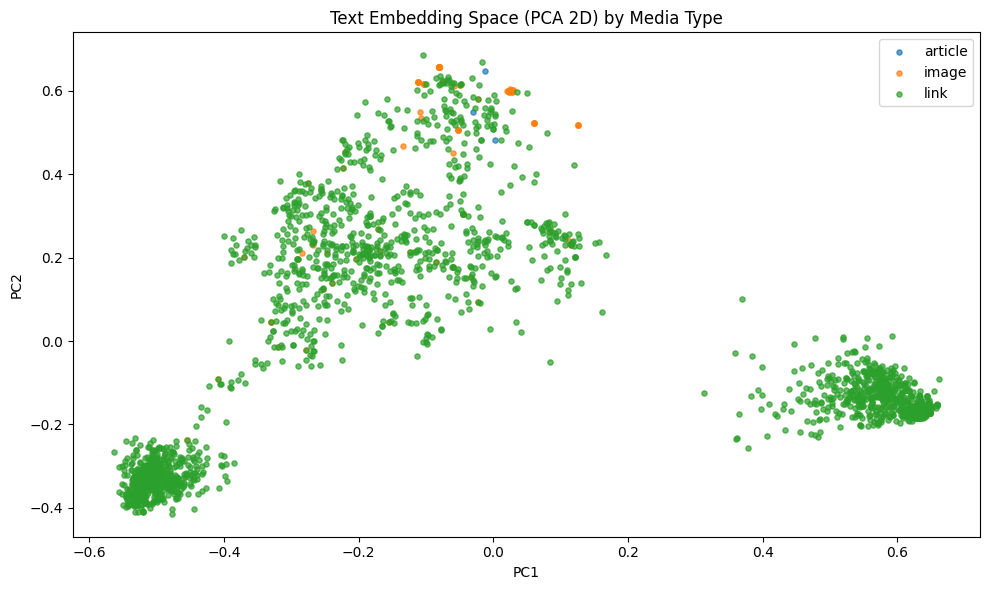

In [10]:
embeddings = []
labels = []
for _, row in df.iterrows():
    vector_str = row.get('text_embedding')
    if not isinstance(vector_str, str):
        continue

    try:
        vector = json.loads(vector_str)
    except json.JSONDecodeError:
        continue

    if not isinstance(vector, list) or len(vector) != 384:
        continue

    embeddings.append(vector)
    labels.append(row.get('media_type') or 'unknown')

if len(embeddings) < 2:
    print('Not enough embeddings to plot PCA.')
else:
    matrix = np.array(embeddings, dtype=np.float64)
    reduced = PCA(n_components=2, random_state=42).fit_transform(matrix)

    plt.figure(figsize=(10, 6))
    unique_labels = sorted(set(labels))
    for media_type in unique_labels:
        idx = [i for i, label in enumerate(labels) if label == media_type]
        points = reduced[idx]
        plt.scatter(points[:, 0], points[:, 1], label=media_type, s=14, alpha=0.7)

    plt.title('Text Embedding Space (PCA 2D) by Media Type')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend()
    plt.tight_layout()
    plt.show()